In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sp = pd.read_csv('StudentsPerformance.csv')


In [31]:
sp

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [32]:
sp.shape

(1000, 8)

In [33]:
sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [34]:
sp.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [35]:
sp.duplicated().sum()

np.int64(0)

In [36]:
sp.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

<hr>

<h5><b>No missing values found

<h5><b>No duplicates found

In [37]:
columns = sp.columns
columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [38]:
sp.rename(columns={
    'race/ethnicity':'race',
    'parental level of education':'parents_education', 
    'test preparation course':'test_preparation_course',
    'math score':'math_score',
    'reading score':'reading_score',
    'writing score':'writing_score'
},inplace=True)

sp.columns

Index(['gender', 'race', 'parents_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [39]:
math_full = sp[sp['math_score']==100]['math_score'].count()
readin_full = sp[sp['reading_score']==100]['reading_score'].count()
writing_full = sp[sp['writing_score']==100]['writing_score'].count()

print(f'{math_full}\n{readin_full}\n{writing_full}')

7
17
14


In [40]:
math_passed = sp[sp['math_score']>=50]['math_score'].count()
readin_passed = sp[sp['reading_score']>=50]['reading_score'].count()
writing_passed = sp[sp['writing_score']>=50]['writing_score'].count()

print(f'passed :\nmath:{math_passed}\nreading:{readin_passed}\nwriting:{writing_passed}')
print(f'faild :\nmath:{1000-math_passed}\nreading:{1000-readin_passed}\nwriting:{1000-writing_passed}')

passed :
math:865
reading:910
writing:886
faild :
math:135
reading:90
writing:114


In [41]:
pass_grade = 50

sp['pass_math'] = 'yes'
filt = (sp['math_score'] < pass_grade)
sp.loc[filt,'pass_math'] = 'no'

sp['pass_reading'] = 'yes'
filt = (sp['reading_score'] < pass_grade)
sp.loc[filt,'pass_reading'] = 'no'

sp['pass_writing'] = 'yes'
filt = (sp['writing_score'] < pass_grade)
sp.loc[filt,'pass_writing'] = 'no'

sp


,gender,race,parents_education,lunch,test_preparation_course,math_score,reading_score,writing_score,pass_math,pass_reading,pass_writing
0,female,group B,bachelor's degree,standard,none,72,72,74,yes,yes,yes
1,female,group C,some college,standard,completed,69,90,88,yes,yes,yes
2,female,group B,master's degree,standard,none,90,95,93,yes,yes,yes
3,male,group A,associate's degree,free/reduced,none,47,57,44,no,yes,no
4,male,group C,some college,standard,none,76,78,75,yes,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,yes,yes,yes
996,male,group C,high school,free/reduced,none,62,55,55,yes,yes,yes
997,female,group C,high school,free/reduced,completed,59,71,65,yes,yes,yes
998,female,group D,some college,standard,completed,68,78,77,yes,yes,yes


In [42]:
pass_math_count = sp.groupby('pass_math')['pass_math'].count()
pass_math_count

pass_math
no     135
yes    865
Name: pass_math, dtype: int64

In [43]:
pass_reading_count = sp.groupby('pass_reading')['pass_reading'].count()
pass_reading_count

pass_reading
no      90
yes    910
Name: pass_reading, dtype: int64

In [44]:
pass_writing_count = sp.groupby('pass_writing')['pass_writing'].count()
pass_writing_count

pass_writing
no     114
yes    886
Name: pass_writing, dtype: int64

<hr>

<Axes: xlabel='writing_score', ylabel='Count'>

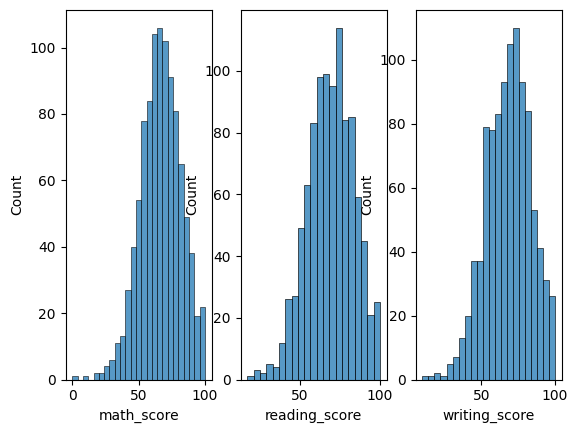

In [49]:
fig,ax= plt.subplots(1,3)

sns.histplot(data=sp,x='math_score',ax=ax[0])
sns.histplot(data=sp,x='reading_score',ax=ax[1])
sns.histplot(data=sp,x='writing_score',ax=ax[2])